In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset pointer
file_path = 'car data.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Car Price dataset loaded successfully!")
else:
    print("Dataset not found. Please ensure 'car data.csv' is placed inside your current folder path.")

# Strip white spaces from columns
df.columns = df.columns.str.strip()
df.head()

Car Price dataset loaded successfully!


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print("--- Missing Values Audit ---")
print(df.isnull().sum())

print("\n--- Feature Datatypes Overview ---")
print(df.info())

print("\n--- Categorical Feature Unique Counts ---")
for col in ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']:
    print(f"{col}: {df[col].unique()}")

--- Missing Values Audit ---
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

--- Feature Datatypes Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

--- Categorical Feature Unique Counts ---
Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Selling_type: [

In [7]:
# Separate features and target
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

# Drop Car_Name as it has too many unique values and causes high cardinality issues
if 'Car_Name' in X.columns:
    X = X.drop(columns=['Car_Name'])

# Automatically group features into numeric and categorical paths
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Define structural column transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Build the unified Supervised Learning Pipeline
car_model_pipeline = Pipeline(steps=[
    ('preprocessing_engine', preprocessor),
    ('regression_algorithm', LinearRegression())
])

# Partition into 80% Training split and 20% Testing validation split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the complete pipeline natively
car_model_pipeline.fit(X_train, y_train)
print("Supervised Regression pipeline trained successfully!")

Supervised Regression pipeline trained successfully!


Mean Absolute Error (MAE): 1.22 Lakhs
Root Mean Squared Error (RMSE): 1.87 Lakhs
Model R-squared (R2) Score: 84.89%


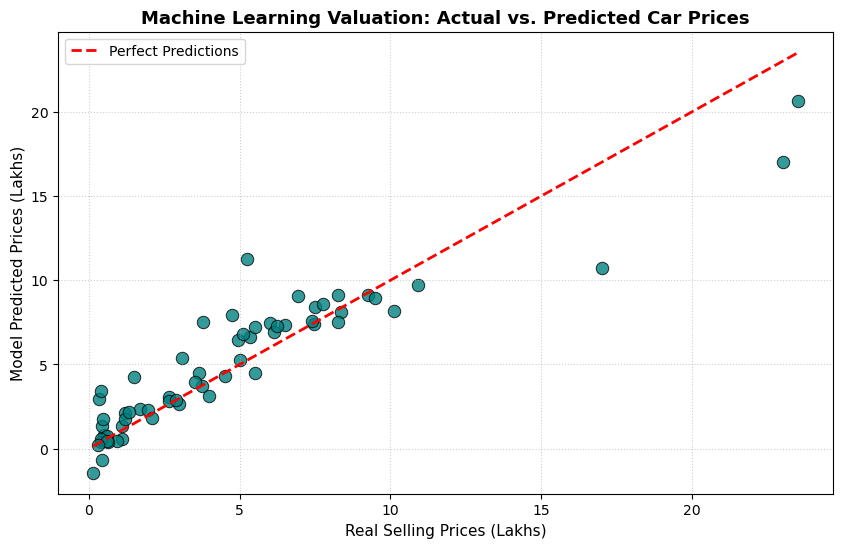

In [8]:
# Predict valuations across validation split
y_pred = car_model_pipeline.predict(X_test)

# Calculate standard accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Lakhs")
print(f"Model R-squared (R2) Score: {r2 * 100:.2f}%")

# Generate Actual vs Predicted Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.8, color='teal', edgecolor='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Predictions')

plt.title('Machine Learning Valuation: Actual vs. Predicted Car Prices', fontsize=13, fontweight='bold')
plt.xlabel('Real Selling Prices (Lakhs)', fontsize=11)
plt.ylabel('Model Predicted Prices (Lakhs)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Save chart asset
plt.savefig('actual_vs_predicted_car_prices.png', dpi=300, bbox_inches='tight')
plt.show()